# CNN - dataset NMIST

En esta Notebook entrenaremos redes neuronales convolucionales (CNN) utilizando el dataset NMIST (dígitos escritos a mano).

***
### 1) Importamos librerías

In [1]:
#Se importan las librerias necesarias
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

from keras.datasets import mnist #cifar10, cifar100
from keras.models import Model
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization #, Activation
from keras.optimizers import Adam #, SGD 
from keras.losses import categorical_crossentropy
from keras.utils import plot_model

In [2]:
#borramos la sesión anterior
keras.backend.clear_session()

`NOTAS`:

La función **keras.backend.clear_session()** se utiliza en Keras para limpiar la memoria y liberar los recursos utilizados por los modelos y las capas anteriores en una sesión de entrenamiento o evaluación. 

Cuando conviene utilizar clear_session():

* Entrenamiento y evaluación repetidos: si estás realizando múltiples iteraciones de entrenamiento y evaluación de modelos en un bucle, es posible que desees llamar a clear_session() al comienzo de cada iteración para asegurarte de que los recursos de memoria se liberen y evitar posibles problemas de falta de memoria.

* Desarrollo iterativo de modelos: durante el desarrollo iterativo de modelos, donde estás ajustando y probando diferentes arquitecturas o configuraciones de modelos, puede ser útil llamar a clear_session() antes de construir y compilar cada nuevo modelo. Esto asegura que cualquier estado anterior del modelo se limpie y no afecte los resultados del nuevo modelo.

* Problemas de memoria: si estás experimentando problemas de falta de memoria durante el entrenamiento o la evaluación de modelos grandes, puedes utilizar clear_session() para liberar la memoria ocupada por los modelos y las capas anteriores antes de construir y compilar un nuevo modelo.

Es importante tener en cuenta que llamar a clear_session() `eliminará todas las capas y modelos previos construidos en la sesión actual`, por lo que debes asegurarte de llamar a esta función en el momento adecuado según tus necesidades específicas.

Si borras la sesión deberás volver a armar la red neuronal y compilar el modelo antes de ajustarlo nuevamente.

***
### 2) Cargamos el dataset

Cargamos el dataset MNIST y realizamos un split de los datos para separar en dos conjuntos: training (60.000 imágenes) y testing (10.000 imágenes).

* xtrain = imágenes de entrenamiento 
* ytrain = etiquetas de entrenamiento

* xtest = imágenes de testeo (evaluación) 
* ytest = etiquetas de testeo (evaluación)

Las imágenes son del tipo grayscale (escala de gris) de 28x28 pixeles y datos uint8, es decir, números entre 0 y 255.


In [3]:
#cargamos y separamos los datos en dos subconjuntos
(xtrain, ytrain), (xtest, ytest )= mnist.load_data()  #los datos son ndarray

print(f"xtrain: {xtrain.shape}")  #60.000 imágenes 28x28x1 
print(f"ytrain: {ytrain.shape}")  #60.000 etiquetas --> números del 0 al 9
print(ytrain[:10])  
print(ytrain.dtype) # datos uint8
print(f"xtest: {xtest.shape}")  
print(f"ytest: {ytest.shape}")

11490434/11490434 [==============================] - 0s 0us/step
xtrain: (60000, 28, 28)
ytrain: (60000,)
[5 0 4 1 9 2 1 3 1 4]
uint8
xtest: (10000, 28, 28)
ytest: (10000,)


In [4]:
# Función para graficar algunas imágenes
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))

    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    
    image = np.concatenate(row_images, axis=0)
    
    plt.imshow(image, cmap ='binary', **options)
    plt.axis("off") 


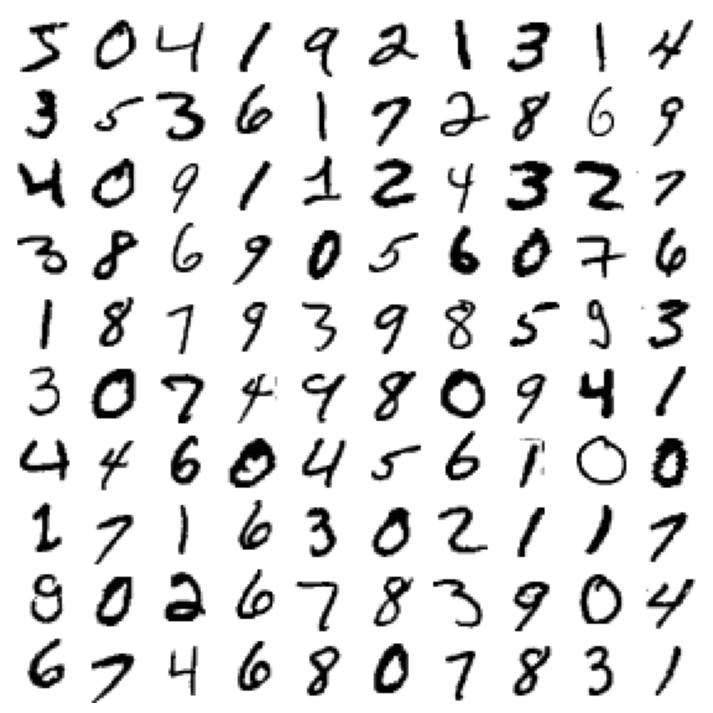

In [ ]:
plt.figure(figsize=(9,9))
plot_digits(xtrain[:100], images_per_row=10)

***
### 3) Preprocesado de las imágenes

Ahora no "achatamos" la imagen como en el Perceptrón Multicapa. En CNN usamos la imagen entera, no como capa densa.

In [5]:
#dimensiones
samples = xtrain.shape[0] # 60000
fil = xtrain.shape[1] #28
col = xtrain.shape[2] #28

#redimensionamos los datos para convertirlos en tensores
#se agrega un 1 (si las imágenes son grayscale) o un 3 (si son RGB)
xtrain = xtrain.reshape(samples, fil, col, 1) #agrego una dimensión más porque las imágenes son escala de gris
# xtrain = xtrain.reshape(-1,28,28,1)  #otra forma de hacerlo, el -1 le indica que utilice todos los samples que tiene

#hacemos lo mismo con el set de testing
xtest = xtest.reshape(xtest.shape[0],fil, col, 1) 

#convertimos los datos de float64 a float32 
xtrain = xtrain.astype('float32')
xtest = xtest.astype('float32')

#normalizamos los datos de entrenamiento
print(f'minimo: {np.min(xtrain)}, máximo: {np.max(xtrain)}') #antes de normalizar (valores entre 0 y 255)
xtrain = xtrain/255
print(f'minimo: {np.min(xtrain)}, máximo: {np.max(xtrain)}') #luego de normalizar (valores entre 0 y 1)

#normalizamos los datos de testing
xtest = xtest/255


minimo: 0.0, máximo: 255.0
minimo: 0.0, máximo: 1.0


***
### 4) Seteo hiperparámetros

El siguiente paso es setear los hiperparámetros que utilizaremos para el entrenamiento de nuestra red neuronal convolucional.

In [6]:
#hiperparámetros
batch_size = 100  #cantidad de imágenes por batch (lote)
num_classes =10   #10 clases: números que van del 0 al 9
epochs = 15       #cantidad de épocas 

***
### 5) One-hot-encoding de labels

Las etiquetas en `ytrain` y `ytest` son números entre 0 y 9.

Lo primero que vamos a hacer es convertir las etiquetas a un encoding *1-de-K*. Para eso, usamos la función  `keras.utils.to_categorical` (similar al `OneHotEncoder` de `sklearn`)

ej: si la etiqueta es un 3 -----> [0 0 0 1 0 0 0 0 0 0]  

La funcion __to.categorical__ convierte el 3 al formato de array (on-hot encoding)

In [7]:
# Convertimos las etiquetas de training y testing a vectores binarios
ytrain = keras.utils.to_categorical(ytrain, num_classes) 
ytest = keras.utils.to_categorical(ytest, num_classes) 

***
### 6) Defino la arquitectura de la red

El próximo paso es la creación de la red neuronal, la cual tendrá capas CONV2D, MaxPooling2D, Flatten y Dense. Se puede agregar Dropout de ser necesario. La última capa FC (o densa) tiene 10 salidas (una por cada clase) y función de activación `softmax`:

In [8]:
#Utilizamos la API funcional:
entradas = Input(shape=(28,28,1)) #tensor de entradas

#ETAPA DE EXTRACCION DE CARACTERISTICAS
x = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(entradas)
x = MaxPooling2D(pool_size=(2, 2))(x) # para reducir el volumen de salida de la CONV2D
x = Conv2D(64, 3, activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, 3, activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
#x = Dropout(0.25)(x)

In [9]:
#ETAPA DE CLASIFICACION
x = Flatten()(x)  #llevamos todo a 1D (array de una dimension) para que las capas Densas lo puedan tratar
x = Dense(128, activation='relu')(x)
salida = Dense(num_classes, activation='softmax')(x) #10 neuronas (1 por cada clase) y función de activación softmax

#Creo el modelo con las entradas y salidas
modelo = Model(inputs=entradas, outputs=salida)
modelo.summary()  #resumen de las capas 

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 128)         73856 

`NOTAS`:

**1er CONV2D**: al tener 32 filtros de 3x3 + 32 bias, la cantidad de parámetros de dicha capa será: 32*3*3+32 = `320 parámetros`

Las capas de **MaxPooling2D** y **Flatten** no tienen parámetros que entrenar.

**2da CONV2D**: 64 filtros de 3x3 y 32 canales de la capa anterior + 64 bias = 64*3*3*32+64 = `18496 parámetros`

**3er CONV2D**: 128 filtros de 3x3 y 64 canales de la capa anterior + 128 bias = 128*3*3*64+128 = `73856 parámetros`

**Flatten**: la salida de la MaxPooling2D previa es 3*3*128 = 1152 neuronas, ningún parámetro

**Dense**: 128 neuronas conectadas a las 1152 de la flatten = 128*1152 = `147584 parámetros`

**Dense salida**: 10 neuronas conectadas a las 128 previas + 10 bias = 10*128+10 = `1290 parámetros`

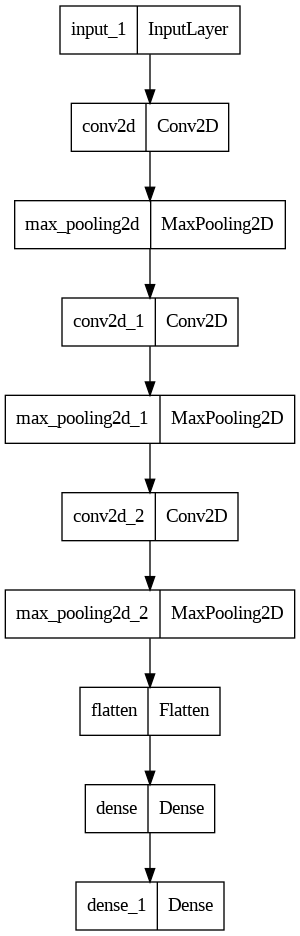

In [10]:
#diagrama en bloques del modelo
plot_model(modelo) 

***
### 7) Compilo el modelo

Luego de crear el modelo, debemos compilarlo (comando `compile`).

Dado que usamos una codificación 1-de-K (one-hot-encoding), necesitamos usar `categorical_crossentropy` como función de pérdida. 

En el caso de utilizar los labeles originales usamos `sparse_categorical_crossentropy`.

Le vamos a pedir al modelo que moniteree la accuracy (aunque podríamos usar otras métricas). 

Debemos definir un optimizador y una función de pérdida:

* **loss**: *categorical_crossentropy* es una funcion de perdida standard para problemas de clasificacion multi-clase.

* **optimizer**: podemos aplicar diferentes optimizadores, cada uno tendrá parámetros que deberemos especificar. Ej: `sgd(lr=0.01, momentum=0.0, decay=0.0, nesterov=False)`

* **metrics**: definimos también una métrica que iremos calculando y guardando para luego visualizarla. Ej: `accuracy`.

In [11]:
 #si las etiquetas fueron codificadas (one-hot encoding)
modelo.compile(optimizer=Adam(), #puedo poner optimizer='adam'
               loss=categorical_crossentropy, 
               metrics=['categorical_accuracy']) 

#si usamos las etiquetas originales (sin codificar one-hot)
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  

`NOTAS`:

En Keras, la métrica "accuracy" y "categorical_accuracy" son dos métricas diferentes que se utilizan para evaluar el rendimiento de un modelo durante el entrenamiento y la evaluación.

La métrica "**accuracy**" es una métrica general que se utiliza para problemas de clasificación. Mide la precisión general del modelo al predecir las etiquetas correctas. Para un problema de clasificación multiclase como MNIST, la métrica "accuracy" calculará la `precisión promedio de todas las clase`s.

Por otro lado, la métrica "**categorical_accuracy**" se utiliza específicamente para problemas de clasificación multiclase cuando las etiquetas se encuentran en una `representación one-hot encoding`. Esta métrica calcula la precisión de las predicciones del modelo considerando si la clase predicha coincide exactamente con la clase verdadera en la representación one-hot. Es decir, compara el valor máximo en la predicción con el valor máximo en la etiqueta one-hot correspondiente.

La diferencia principal entre estas dos métricas radica en cómo tratan las etiquetas. "accuracy" se puede usar en problemas de clasificación binaria y multiclase, mientras que "categorical_accuracy" está específicamente diseñada para clasificación multiclase con etiquetas one-hot.

En la mayoría de los casos, cuando trabajas con un problema de clasificación multiclase en Keras, especialmente si has codificado tus etiquetas en forma one-hot, es recomendable utilizar "categorical_accuracy" para evaluar el rendimiento de tu modelo.

La función de pérdida **sparse_categorical_crossentropy** se utiliza en problemas de clasificación multiclase `cuando las etiquetas de clase son enteros` en lugar de una representación one-hot. Es decir, cuando las etiquetas no están codificadas mediante one-hot encoding.

Cuando utilizas sparse_categorical_crossentropy, no es necesario convertir las etiquetas en una representación one-hot. En su lugar, puedes pasar directamente los enteros como etiquetas en su forma original al modelo.

Al utilizar **sparse_categorical_crossentropy** como función de pérdida, Keras realizará automáticamente la conversión interna de las etiquetas de clase enteras a una representación one-hot antes de calcular la pérdida y la métrica. Por lo tanto, puedes utilizar directamente la métrica **accuracy** sin la necesidad de realizar ninguna conversión manualmente.

Durante el entrenamiento o evaluación del modelo, la métrica accuracy proporcionará la precisión del modelo en términos de la clasificación correcta de las etiquetas de clase, tomando en cuenta las etiquetas enteras originales sin la necesidad de convertirlas a una representación one-hot.

***
### 8) Entrenamiento del modelo (fit)

El comando **fit** me permite entrenar el modelo. A dicho comando debo pasarle diferentes parámetros:

* `xtrain`: imágenes de entrenamiento 

* `ytrain`:  etiquetas de las imágenes de entrenamiento en formato categórico.

* `batch_size`: tamaño de los paquetes (batches o lotes) de imágenes

* `epochs`: el número de épocas (iteraciones de todo el dataset completo) que va a entrenar

* `verbose`: establece si el comando fit nos devuelve información. Con verbose=0, no nos informa nada; con verbose=1 nos da toda la info; verbose=2 info por época.

* `validation_data`: especificamos los datos (imágenes y labels) de validación.

* `validation_split`: porcentaje de los datos de entrenamiento que serán utilizados para validación.

Guardamos el output del método `fit` en la variable `history`. Vamos a poder ver la evolución del proceso de entrenamiento.

Añadimos el argumento de `validation_data` para monitear la performance sobre datos no vistos.


In [12]:
history = modelo.fit(xtrain, ytrain, batch_size=batch_size, epochs=epochs, validation_split=0.10, verbose=1)

# Podemos usar `history` para graficar el entrenamiento
print(history.history.keys())

Epoch 1/15
540/540 [==============================] - 11s 5ms/step - loss: 0.2048 - categorical_accuracy: 0.9376 - val_loss: 0.0495 - val_categorical_accuracy: 0.9852
Epoch 2/15
540/540 [==============================] - 2s 5ms/step - loss: 0.0482 - categorical_accuracy: 0.9847 - val_loss: 0.0635 - val_categorical_accuracy: 0.9798
Epoch 3/15
540/540 [==============================] - 2s 5ms/step - loss: 0.0328 - categorical_accuracy: 0.9896 - val_loss: 0.0286 - val_categorical_accuracy: 0.9922
Epoch 4/15
540/540 [==============================] - 3s 5ms/step - loss: 0.0241 - categorical_accuracy: 0.9922 - val_loss: 0.0287 - val_categorical_accuracy: 0.9912
Epoch 5/15
540/540 [==============================] - 4s 7ms/step - loss: 0.0187 - categorical_accuracy: 0.9938 - val_loss: 0.0213 - val_categorical_accuracy: 0.9935
Epoch 6/15
540/540 [==============================] - 4s 7ms/step - loss: 0.0154 - categorical_accuracy: 0.9950 - val_loss: 0.0368 - val_categorical_accuracy: 0.9910
Epo

`NOTAS`:

Cuando ajustamos un modelo, generalmente utilizamos conjuntos de datos separados para entrenamiento, validación y prueba (testing). La división típica es la siguiente:

**Training set**: este conjunto de datos se utiliza para entrenar el modelo. El modelo ajusta sus parámetros basándose en estos datos durante el proceso de entrenamiento.

**Validation set**: este conjunto de datos se utiliza para ajustar los hiperparámetros del modelo y evaluar su rendimiento durante el entrenamiento. Se utiliza para realizar ajustes y mejoras en el modelo. Es un porcentaje extraido del set de entrenamiento.

**Test set**: este conjunto de datos se utiliza para evaluar el rendimiento final del modelo después de que se ha ajustado y se ha seleccionado el mejor modelo basado en los resultados de validación. El conjunto de prueba proporciona una evaluación imparcial del rendimiento del modelo y se utiliza para estimar cómo el modelo generalizará a datos no vistos previamente.

La idea principal es que el conjunto de prueba no se utiliza durante el ajuste del modelo, para evitar que el modelo "aprenda" o se ajuste específicamente a esos datos de prueba. En cambio, se utiliza solo después del ajuste del modelo para evaluar su rendimiento final.

No hay una regla estricta sobre los porcentajes específicos que se deben usar para los conjuntos de entrenamiento, validación y prueba, ya que puede variar dependiendo del tamaño del dataset y de la naturaleza del problema.

Sin embargo, hay algunas prácticas comunes que se pueden seguir:

*Training set*: por lo general, se asigna la mayor proporción del dataset al conjunto de entrenamiento. Puedes utilizar alrededor del 60-80% de los datos, dependiendo de la disponibilidad de datos y la complejidad del problema. Cuanto más datos de entrenamiento se utilicen, mejor será la capacidad del modelo para aprender patrones y generalizar.

Validation set *texto en cursiva*: el conjunto de validación se utiliza para ajustar los hiperparámetros del modelo y evaluar su rendimiento durante el entrenamiento. Generalmente, se reserva entre el 10% y el 20% de los datos de entrenamiento para el conjunto de validación. El tamaño del conjunto de validación puede variar según la cantidad total de datos disponibles y la cantidad de combinaciones de hiperparámetros que deseas probar.

*Test set*: por lo general, se reserva alrededor del 10-20% de los datos para el conjunto de prueba. 

Es importante tener en cuenta que estos porcentajes son solo una guía general y se pueden ajustar según las necesidades específicas del problema y la disponibilidad de datos. 

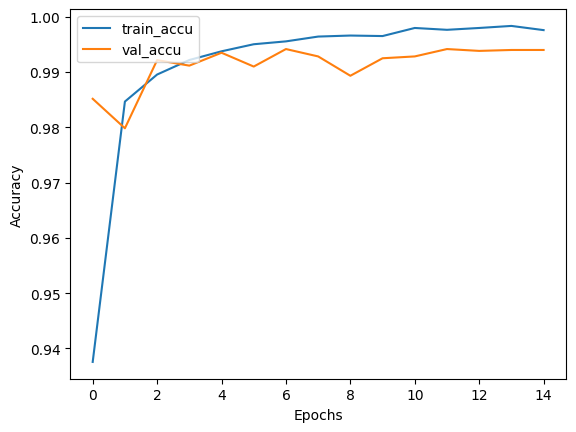

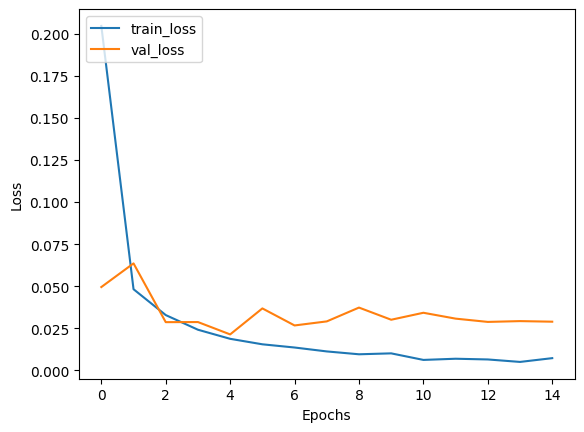

In [13]:
#graficamos la historia del entrenamiento
plt.figure(1)
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train_accu', 'val_accu'], loc='upper left')

plt.figure(2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train_loss','val_loss'], loc='upper left')


***
### 9) Salvamos el modelo

* Opción1: grabamos el modelo a un formato especial (*.h5).

* Opción2: podemos guardar la arquitectura y los pesos entrenados usando un callbacks (ver *Notebook U2_callbaks.ipynb*).

In [14]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [15]:
#Opción 1: 
modelo.save(f'/content/gdrive/My Drive/DL/U2/CNN.h5')

***
### 10) Evaluamos el modelo

Nos da una puntuación,  nos dice que bien generaliza nuestro modelo (con datos nunca vistos: testing).

In [16]:
test_loss, test_accuracy  = modelo.evaluate(xtest, ytest, verbose = 1)
print(f"Puntuación final: loss {test_loss}, accuracy {test_accuracy}")

313/313 [==============================] - 1s 3ms/step - loss: 0.0315 - categorical_accuracy: 0.9912
Puntuación final: loss 0.03151417896151543, accuracy 0.9911999702453613


***
### 11) Predicción usando el modelo

Empleando el modelo entrenado (ajustado), le pasaremos alguna imagen para que nos infiera a qué clase pertenece.

El elemento 52 del conjunto de datos de test (xtest) es:


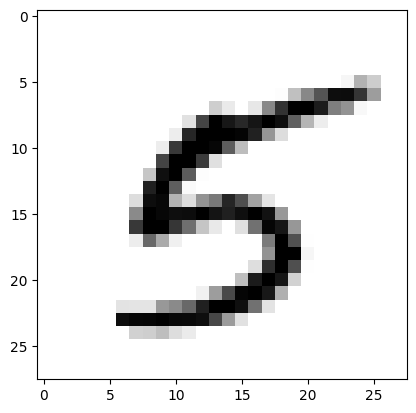

313/313 [==============================] - 1s 2ms/step
PREDICCION: el número es 5:


In [17]:
print("El elemento 52 del conjunto de datos de test (xtest) es:")
plt.imshow(xtest[52].reshape((28, 28)), cmap=plt.cm.binary)
plt.show()

predictions = modelo.predict(xtest)
print("PREDICCION: el número es {}:".format(np.argmax(predictions[52])))

***
### RESUMEN:

Notemos que en la primera capa se especifica el *input_shape*. Esto alcanza para especificar cuántos pesos tiene cada capa posterior. La primera capa no tiene parámetros, es solo una transformación de datos (que aplana la matriz en un vector).

La función de activación es muy importante: sobre ellas recae toda la no-linearidad del modelo. 

En las capas internas, se suele utilizar `tanh` (para redes poco profundas) y `ReLU` (para redes profundas).

En la última capa, la función de activación depende del problema a resolver:

* Clasificación: Se puede usar una sigmoide (para clasificación binaria) o una softmax (para multi-clase).

* Regresión: Las regresiones sin restricciones generalmente no usan ninguna función de activación, la última capa es solo un modelo lineal. Si queremos imponer alguna restricción, podemos usar un ReLU para salidas limitadas en un lado, o su versión suavizada `softplus`, y un` sigmoide` o un `tanh` para salidas limitadas en ambos lados.

In [18]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'swish',
 'tanh']

***
**COMPILACION**:

Una vez que el modelo está instanciado, necesitamos _"compilarlo"_ antes de poder usarlo. Keras creará el grafo de ejecución de TensorFlow.

En este paso, se definen las piezas faltantes de nuestro modelo:

* **función de pérdida**, la que buscaremos minimizar. 
* **optimizador** que se usa para minimizar la pérdida (ej. SGD).
* **métricas** que se quieren visualizar durante el entrenamiento.

La `función de pérdida` define el problema que intentaremos resolver y está íntimamente relacionada con la `función de activación de la capa de salida`. 

Para un problema de `clasificación binaria`, normalmente estaremos en una de estas dos situaciones:

* Una neurona en la capa de salida: modelamos la probabilidad de asignación a una de las dos clases. La función de activación es una **sigmoide**, por lo que la salida es un número real entre 0 y 1, y la función de pérdida es la **binary_cross_entropy**. 

* Dos neuronas en la capa de salida: queremos modelar la probabilidad de asignación a cada una de las clases. Las salidas de estos dos neuronas deben estar entre 0 y 1 y sumar 1, por lo que la función de activación adecuada es la **softmax**. La función de pérdida correspondiente debe ser la misma, solo que cuando el número de neuronas coincide con el número de clases, se reescribe  para la clasificación de clases múltiples: **categorical_cross_entropy**. 

Dicha función está definida para usarse con targets (labeles) codificados *one-hot-encoded*. En el caso de usar un codificador ordinal, podemos transformar nuestros targets usando `tensorflow.keras.utils.to_categorical`, o emplear la función de pérdida **sparse_categorical_cross_entropy**.

Para un problema `multi-clase`, se puede usar una función de activación softmax y seguir las mismas consideraciones que en el segundo caso.


***
**ENTRENAMIENTO**:

Entrenar un modelo en Keras es tan simple como ejecutar el método 'fit'. Entre los parámetros que podemos configurar tenemos el número de épocas, el tamaño del batch y los datos de validación que podemos usar para ver la evolución de las métricas (definidas en el paso de compilación).

El método 'fit' devuelve un objeto historia, que contiene toda la información del entrenamiento en diccionarios. Esto permite analizar el entrenamiento de nuestro modelo.

El atributo `history` devuelve las métricas de entrenamiento, que se pueden plotear: history.history.keys()

***
**EVALUACION**:

Para evaluar la performance del modelo en el conjunto de test o validación, se puede utilizar el método `evaluate`.

***
**PREDICCION**:

Para hacer predicciones en nuevos datos, usamos el método `predict`, que devuelve las probabilidades de cada clase: 

y_proba = model.predict(X_new)

Se pueden usar las probabilidades para asignar clases:

y_pred = np.argmax(y_proba, axis=1)


***
**SALVAR - CARGAR MODDELOS**:

Para salvar nuestros modelos entrenados, necesitamos salvar dos cosas: la estructura de la red y los pesos.

Esto es más eficiente que hacer un _pickle_ de toda la clase, Keras provee sencillos métodos para salvar y cargar modelos usando el formato H5:

**model.save**("my_keras_model.h5")

Luego se puede cargar con:

model = **keras.models.load_model**("my_keras_model.h5")

Una opción más liviana es simplemente salvar los pesos de cada capa:

**model.save_weights**("my_keras_weights.ckpt")

Antes de cargar los pesos, necesitamos definir la arquitectura del modelo, y tiene que ser idéntica al que se usó en el entrenamiento.

**model.load_weights**("my_keras_weights.ckpt")

Esta opción puede ser útil para salvar diferentes etapas del proceso de entrenamiento

***
**API FUNCIONAL**:

Aqui vemos un ejemplo de como podemos usar la API funcional para hacer modelos mas complejos. En el modelo [Wide and Deep](https://https://ai.google/research/pubs/pub45413) se conectan los inputs directamente a los outputs, ademas de pasando por una red profunda de dos capas. De esta manera, el modelo puede aprender features mas abstractos de los datos, y a la vez tomarlos directamente sin distorisión.

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 dense_2 (Dense)                (None, 28, 28, 30)   60          ['input_2[0][0]']                
                                                                                                  
 dense_3 (Dense)                (None, 28, 28, 30)   930         ['dense_2[0][0]']                
                                                                                                  
 concatenate (Concatenate)      (None, 28, 28, 31)   0           ['input_2[0][0]',                
                                                                  'dense_3[0][0]']          

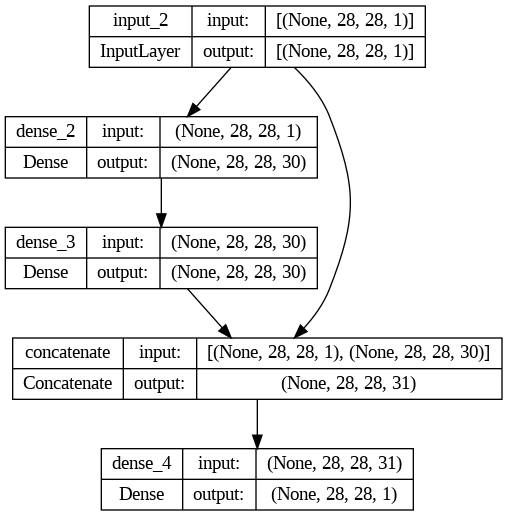

In [19]:
input_ = keras.layers.Input(shape=xtrain.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])

model.summary()

keras.utils.plot_model(model, "wide_and_deep_model.png", show_shapes=True)

***
**CALLBACKS**:

Los *callbacks* son funciones que podemos especificar que se ejecuten durante el entrenamiento. Por ejemplo, podemos indicarle a nuestro modelo que se salve al final de cada época, o implementar un _EarlyStopping_ para detener el ajuste si la métrica de validación no mejora. Incluso podemos definir nuestros propios *Callbacks* para, por ejemplo, enviarnos un email periódicamente un con las métricas del entrenamiento.

Los *callbacks* se pasan al método `fit`.


In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5", save_best_only=True)
history = model.fit(xtrain, ytrain, epochs=30, validation_data=(xtest, ytest), callbacks=[checkpoint_cb])

In [ ]:
model = keras.models.load_model("my_keras_model.h5")

***
**EARLY STOPPING**:

Este procedimiento se encarga de detener el paso de entrenamiento analizando las métricas de validación y, cuando el aumento del score ya no es significativo para un cierto número de iteraciones, detiene el entrenamiento.

Para implementar este _callback_ en keras hay que indicar la métrica a monitorear el delta mínimo y la _paciencia_. Tambien provee una forma de guardar los pesos del mejor modelo, de forma tal que cuando el entrenamiento termina son restaurados esos valores

model.fit(xtrain, ytrain, epochs=30, validation_data=(xtest, ytest), 
callbacks=[keras.callbacks.EarlyStopping(patience=10)])


***
**DROPOUT**:

En dos artículos de 2012 y 2014 se propuso una forma de regularizar las redes neuronales profundas: en cada paso de entrenamiento, algunas de las neuronas tienen una probabilidad $p$ de "apagarse" (sus salidas se ponen en cero). Esto se hace solo durante el entrenamiento y, para la predicción, todas las neuronas están encendidas (y sus pesos se vuelven a ponderar correctamente para tener en cuenta el aumento de $1/p$ en la señal).

La idea principal detrás de esto es obligar a la red a no depender demasiado de ninguna neurona en particular, forzándola a ofrecer buenos resultados incluso cuando esa neurona está apagada. Existen también algunas variantes de este modelo, como Alpha-Dropout y MCDropout.

En Keras, este tipo de regularización se ha implementado como una Capa, por lo que solo necesitamos importarla e instanciarla. La probabilidad de desconexión $p$ se establece a través del parámetro 'rate', y la capa se encarga de _backpropagar_ la señal de manera adecuada y, así como de ajustar los pesos para la evaluación y predicción.


***
**VANISHING-EXPLODING GRADIENTS**:

Debido a la naturaleza misma del _backpropagation_, los gradientes son inestables a través de las capas y la velocidad a la que aprende cada una depende de la profundidad a la que se encuentra. La naturaleza multiplicativa del _backpropagation_ hace que cualquier aumento/disminución coordinado en los gradientes se exponencialice a medida que se retropropaga a través de la red:

* Si los gradientes disminuyen a medida que vamos hacia atras en la red, las capas cercanas a la entrada van a cambiar a un ratio mucho más pequeño que aquellas que están más cercanas a la salida. Esto puede evitar que la red converga a una solución óptima, este problema es conocido como *vanishing gradient* y es la causa de que los tiempos de aprendizaje se incrementen significativamente. 
* Si los gradientes aumentan a medida que vamos hacia atras, el algoritmo comienza a diverger. Este es el problema del *exploding gradient*, y directamente evitan la convergencia del sistema.

***
**OPTIMIZADOR**:

El optimizador es el algoritmo que dice cómo cambiar los pesos del modelo para disminuir la pérdida. Es una parte crucial del algoritmo. Ya hemos visto un algoritmo, que es la base de todos los demás, Descenso de gradiente estocástico, pero hay muchos otros:

In [ ]:
[name for name in dir(keras.optimizers) if (not name.startswith("_") and name[0].isupper())]

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD']

Por default, la implementación de Keras de SGD soporta algunas variantes básicas, como optimización de momento:

$\vec{m}\rightarrow \beta \vec{m} -\eta \nabla_{\vec{\theta}} J(\vec{\theta}) $

$\vec{\theta} \rightarrow \vec{\theta} + \vec{m}$

optimizer = keras.optimizers.SGD(lr=0.001, momentum=0.9)

y sus variantes, el gradiente acelerado de Nesterov:

$\vec{m}\rightarrow \beta \vec{m} -\eta \nabla_{\vec{\theta}} J(\vec{\theta}+\beta\vec{m}) $

$\vec{\theta} \rightarrow \vec{\theta} + \vec{m}$

optimizer = keras.optimizers.SGD(lr=0.001, momentum=0.9, nesterov=True)

También hay algunas otras modificaciones, cuya intención es escalar la tasa de aprendizaje para aumentarla en la dirección donde el cambio es pequeño, para acelerar la convergencia.

El primer ejemplo de tal algoritmo es el método `AdaGrad`

optimizer = keras.optimizers.Adagrad(lr=0.001)

Pero una variante que normalmente funciona mejor es el `RMSProp`,que introduce un decaimiento exponencial en el impulso, controlado por un parámetro $\rho$  (normalmente ~0,9), y de esta forma evita el problema de AdaGrad de sobreadaptar la tasa de aprendizaje.

optimizer = keras.optimizers.RMSprop(lr=0.001, rho=0.9)

Y una combinación popular de `RMSProp` con optimización de momento, que parece funcionar bastante bien, es el optimizador `Adam`. El parámetro `beta_1` controla la optimización de momento, el` beta_2` controla el RMSProp y `epsilon` es un número pequeño para evitar la división por cero. 

optimizer = keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)

Existen también algunas variantes de Adam, Adamax y Nadam, pero no son tan usadas.

optimizer = keras.optimizers.Adamax(lr=0.001, beta_1=0.9, beta_2=0.999)
optimizer = keras.optimizers.Nadam(lr=0.001, beta_1=0.9, beta_2=0.999)

***
**LEARNING RATE**:

El hiperparámetro más importante que tenemos para tunear el entrenamiento de las redes neuronales y acelerar su convergencia, es la tasa de aprendizaje. Hemos visto que algunos optimizadores, como Adam, son menos sensibles al valor inicial de la tasa de aprendizaje, pero aún así es una buena idea hacer un uso más eficiente de la misma.

Una idea es probar diferentes velocidades de aprendizaje y ver la velocidad a la que disminuye la pérdida (un proceso que se conoce como _one-cycle learning_ (aprendizaje de un ciclo). Pero incluso si hacemos esto, una estrategia común para evitar estancamientos en el aprendizaje es disminuir lentamente la tasa de aprendizaje a medida que avanza el entrenamiento. Esto se conoce como **Learning Rate Scheduling** (Programación de la tasa de aprendizaje) y se puede implementar con un callback.

Para definir un schedule, debemos especificar como escalar la tasa de aprendizaje como una función de la época. Una forma de hacerlo es a través de un _Power Scheduling_:
$$\eta = \frac{\eta_{0}}{(1+\text{epoch}/s)^{c}}$$

En este caso, se implementa automáticamente en el optimizador SGD, seteando:

$c=1$ y $s = 1/$decay:

optimizer = keras.optimizers.SGD(lr=0.01, decay=1e-4)

Otra opción común es introducir un scheduling exponencial con un callbak, que reduce drásticamente la tasa de aprendizaje en cada paso

$\eta = \eta_{0}\cdot0.1^{\text{epoch}/s}$

Para implementar esto, podemos usar `keras.callbacks.LearningRateScheduler` al que le podemos pasar una función arbitraria de época, y usarla como un callback.

In [ ]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1**(epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.01, s=20)

#this is the same as defining
#def exponential_decay_fn(epoch):
#    return 0.01 * 0.1**(epoch / 20)

lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)